# 02 / 물리 기반 피처 엔지니어링 - AI4I 2020

**목표:** 원본 센서를 기계공학 도메인을 활용하여 **물리량**으로 변환한다.
Phase 1에서 확보한 근거(회전속도-토크 반비례 등)를 실제 피처로 구현.

| 파생 피처 | 유도식 | 겨냥하는 고장 |
|---|---|---|
| 각속도 omega | 2*pi*N/60 | (동력 계산의 중간량) |
| 기계 동력 P | tau*omega | 전력/동력 이상 (PWF) |
| 온도차 dT | 공정온도 - 공기온도 | 방열 실패 (HDF) |
| 누적 응력 | 공구마모 x 토크 | 과부하 파손 (OSF) |

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

_here = Path.cwd()
ROOT = next((p for p in [_here, *_here.parents] if (p / 'src').is_dir()), _here)
sys.path.insert(0, str(ROOT))
from src.config import FIGDIR, FEATURES_CSV, load_raw
from src.physics import (add_physics_features, check_invariants,
                         COL_OMEGA, COL_POWER, COL_DT, COL_STRAIN)

FIGDIR.mkdir(parents=True, exist_ok=True)

df = load_raw()
target = 'Machine failure'
print('원본 shape:', df.shape)

원본 shape: (10000, 14)


## 1. 물리 파생 피처 생성

In [2]:
feat = add_physics_features(df)
new_cols = [COL_OMEGA, COL_POWER, COL_DT, COL_STRAIN]
print('추가된 피처:', new_cols)
feat[['Torque [Nm]', 'Rotational speed [rpm]'] + new_cols].head()

추가된 피처: ['Angular velocity [rad/s]', 'Mechanical power [W]', 'Temp difference [K]', 'Overstrain [min*Nm]']


,Torque [Nm],Rotational speed [rpm],Angular velocity [rad/s],Mechanical power [W],Temp difference [K],Overstrain [min*Nm]
0,42.8,1551,162.420340,6951.590560,10.5,0.0
1,46.3,1408,147.445415,6826.722724,10.5,138.9
2,49.4,1498,156.870193,7749.387543,10.4,247.0
3,39.5,1433,150.063409,5927.504659,10.4,276.5
4,40.0,1408,147.445415,5897.816608,10.5,360.0


## 2. 검증

- 물리 부호 불변식: dT>0(공정이 항상 주변보다 뜨거움), P>0, omega>0.
- 내부 정합성: 계산이 정의(P=tau*omega 등)대로인지.

In [3]:
# 참고용 분포
print(feat[new_cols].describe().T[['mean', 'std', 'min', 'max']].round(1).to_string())

# 데이터 독립 불변식 점검
print('\n[불변식 점검]')
inv = check_invariants(feat)
for name, ok in inv.items():
    print(f'  {"PASS" if ok else "FAIL"}  {name}')
assert all(inv.values()), '불변식 위반'
print('\n동력 크기(외부 도메인 기대): 회전기계이므로 kW대여야 함 ->',
      f'중앙값 {feat[COL_POWER].median():.0f} W (OK, kW 자릿수).')

                            mean     std     min      max
Angular velocity [rad/s]   161.1    18.8   122.3    302.2
Mechanical power [W]      6279.7  1067.4  1148.4  10469.9
Temp difference [K]         10.0     1.0     7.6     12.1
Overstrain [min*Nm]       4314.7  2826.6     0.0  16497.0

[불변식 점검]
  PASS  omega > 0
  PASS  P > 0
  PASS  dT > 0 (process hotter than ambient)
  PASS  omega == 2*pi*N/60
  PASS  P == tau*omega
  PASS  strain == wear*tau

동력 크기(외부 도메인 기대): 회전기계이므로 kW대여야 함 -> 중앙값 6271 W (OK, kW 자릿수).


## 3. 파생 피처 분포

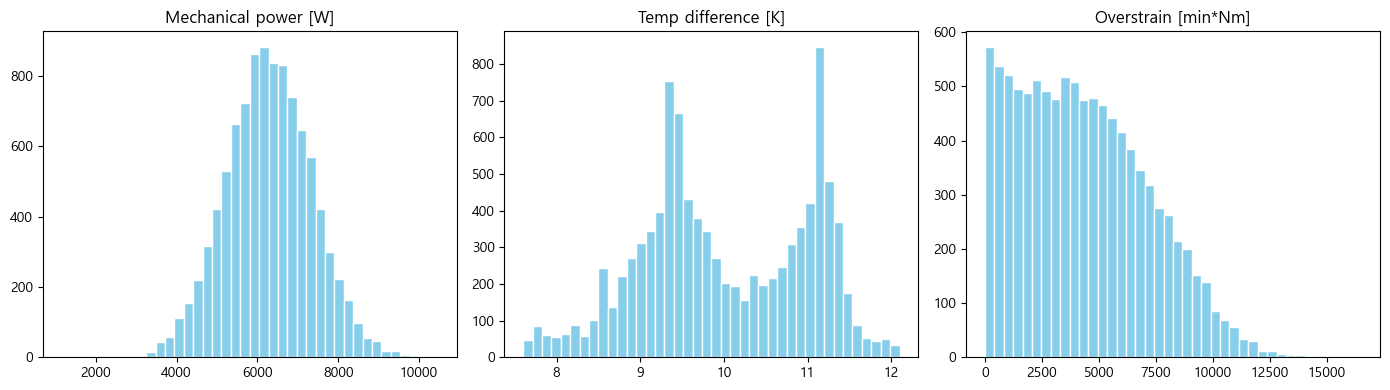

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, [COL_POWER, COL_DT, COL_STRAIN]):
    ax.hist(feat[col], bins=40, color='skyblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIGDIR / '02_derived_distributions.png', dpi=120)
plt.show()

## 4. 검증 1)  동력 P가 고장과 관련되나

동력 피처를 파생한 근거는 "P가 정상범위를 벗어나면 동력 이상"이라는 가정이다.
PWF 고장이 P 분포에서 어디에 위치하는지 관찰한다.

P 범위: [1148, 10470] W, 중앙값 6271 W
PWF 고장의 P: 최소 1148, 최대 10470 W
=> PWF가 P 분포의 양 극단(저/고)에 위치 = 양방향 신호.


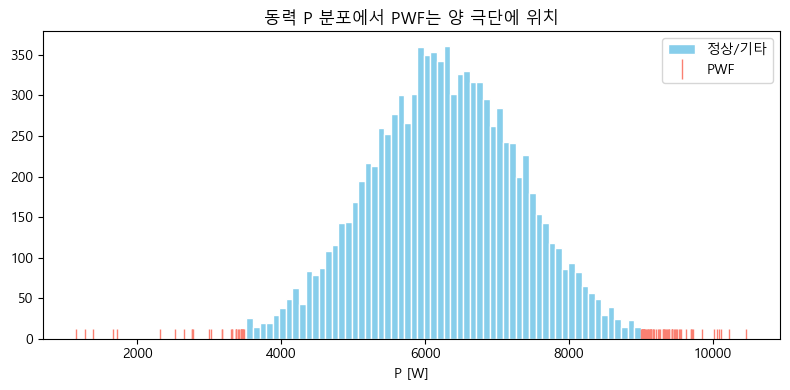

In [5]:
p = feat[COL_POWER]
pwf = feat['PWF'] == 1
print(f'P 범위: [{p.min():.0f}, {p.max():.0f}] W, 중앙값 {p.median():.0f} W')
print(f'PWF 고장의 P: 최소 {p[pwf].min():.0f}, 최대 {p[pwf].max():.0f} W')
print('=> PWF가 P 분포의 양 극단(저/고)에 위치 = 양방향 신호.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(p[~pwf], bins=60, color='skyblue', edgecolor='white', label='정상/기타')
ax.plot(p[pwf], np.zeros(int(pwf.sum())), '|', color='salmon', markersize=14, label='PWF')
ax.set_title('동력 P 분포에서 PWF는 양 극단에 위치')
ax.set_xlabel('P [W]')
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / '02_power_vs_pwf.png', dpi=120)
plt.show()

## 5. 검증 2)  동력 P가 tau*N 두 변수를 하나로 압축하는가

Phase 1에서 tau와 N은 강한 반비례였다. P=tau*omega는 이 둘을 곱으로 묶어
"실제 부하 수준"이라는 단일 축으로 만든다.

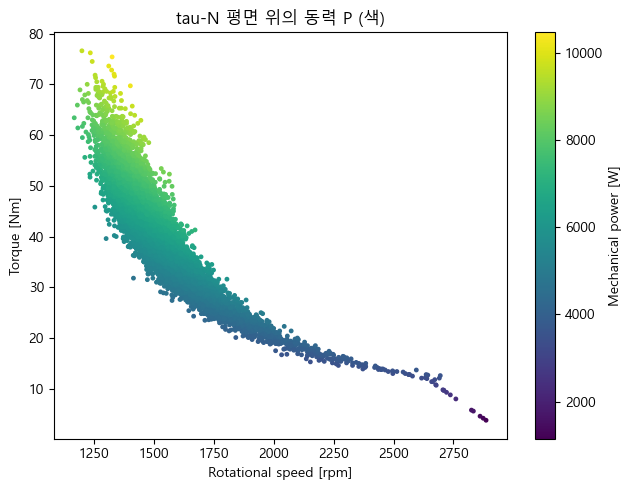

반비례 곡선을 따라 P가 등고선처럼 변함 -> P가 tau*N을 물리적으로 설명


In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(feat['Rotational speed [rpm]'], feat['Torque [Nm]'],
                c=feat[COL_POWER], cmap='viridis', s=6)
ax.set_xlabel('Rotational speed [rpm]')
ax.set_ylabel('Torque [Nm]')
ax.set_title('tau-N 평면 위의 동력 P (색)')
plt.colorbar(sc, label=COL_POWER)
plt.tight_layout()
plt.savefig(FIGDIR / '02_power_on_tau_n.png', dpi=120)
plt.show()
print('반비례 곡선을 따라 P가 등고선처럼 변함 -> P가 tau*N을 물리적으로 설명')

## 6. 파생 피처 <-> 타깃 - 원신호보다 잘 설명하는가

각 파생 피처를 정상/고장으로 나눠 비교.

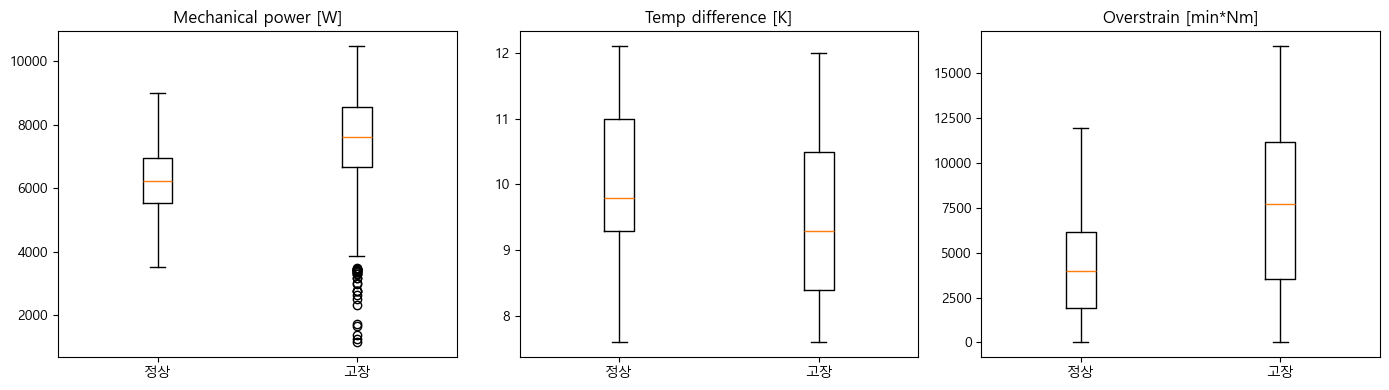

Mechanical power [W]   정상   6244.5 | 고장   7282.8 | 차  +1038.3
Temp difference [K]    정상     10.0 | 고장      9.4 | 차     -0.6
Overstrain [min*Nm]    정상   4213.8 | 고장   7187.9 | 차  +2974.1


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, [COL_POWER, COL_DT, COL_STRAIN]):
    ax.boxplot([feat.loc[feat[target] == 0, col], feat.loc[feat[target] == 1, col]],
               tick_labels=['정상', '고장'])
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIGDIR / '02_derived_vs_target.png', dpi=120)
plt.show()

for col in [COL_POWER, COL_DT, COL_STRAIN]:
    g0 = feat.loc[feat[target] == 0, col]
    g1 = feat.loc[feat[target] == 1, col]
    print(f'{col:22} 정상 {g0.mean():8.1f} | 고장 {g1.mean():8.1f} | 차 {g1.mean()-g0.mean():+8.1f}')

## 7. 저장

파생 피처를 포함한 데이터를 `data/processed/` 에 저장해 이후 단계에서 재사용.

In [8]:
FEATURES_CSV.parent.mkdir(parents=True, exist_ok=True)
feat.to_csv(FEATURES_CSV, index=False, encoding='utf-8-sig')
print('저장:', FEATURES_CSV.name)
print('최종 shape:', feat.shape, '| 추가 피처 4종 포함')

저장: ai4i_features.csv
최종 shape: (10000, 18) | 추가 피처 4종 포함


## 결론 (Phase 2)

- 동력 P/온도차 dT/누적응력을 기계공학 도메인 기반 1차 원리로 파생, **단위/범위 물리적 타당** 확인(불변식+단위테스트).
- P가 tau*N 두 변수를 하나로 통합함을 시각 확인.
- 파생 피처가 고장/정상을 원신호보다 뚜렷이 가름 관측(P는 양방향, dT/응력은 단방향).